# Alignments for the Wavefront Sensor

francisho@lbl.gov, Nov 2025

(based on script by awojdyla@lb.gov, Sept 2024)


## Experimental setup 

Two motors:
- Linear: Positive for moving up, negative for moving down. 
- Rotary: 1 for a cycle (360 degree). 

YAG + Camera: 
- 4096*3000 pixels
- Need to verify pixel size (3.45 um?) and "to-camera" distance (150 mm?)

Laser aligner--using the vertical line. 


# SETUP


## Import 

(if there is an issue, do !pip instal package and restart the kernel)

In [1]:
import sys
import time

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from pypylon import pylon

In [2]:
# location of a berkeley lab specific python to reac labview through tcp port
sys.path.append("C:\\Users\\lbnl-guest\\python")
import bcs_tcp

## Connecting to Camera and Motors

For motors, first make sure LabView is running. 

In [4]:
camera = pylon.InstantCamera(pylon.TlFactory.GetInstance().CreateFirstDevice())
# camera ip is 192.168.10.70
# a2A1920-51gcBAS (3000, 4096), ? um pixel size
# px_um = 3.45 ?
# distance to camera 150 mm ?
d_m = 0.15

In [5]:
# Control motor through bcs tcp interface
(host_ip_addr, host_port, host_timeout) = ('localhost',55000,5)
bcs = bcs_tcp.connection(host_ip_addr, host_port, host_timeout)

# Identify strings
bcs_id_linear = 'Galil x.20 A'  # linear stage
bcs_id_rotary = 'Galil x.20 B'  # rotary stage

# Raw data access -- please avoid, for debugging only
# pos = bcs.GetMotorPos(bcs_id_rotary)
# print(pos)

### Custom function to record rotary motor position

Since the rotary motor angle is not recorded, we manually define a state viarable `rotary_motor_rev` to record its angular position:
- When `rotary_motor_rev = 0`, the optical path is fully OPEN; 
- When `rotary_motor_rev = 0.5`, the optical path is fully CLOSED (i.e., the beam is reflected to the YAG); 
- When `rotary_motor_rev = 1`, the value will become `0` again. 
- To avoid backlash, one can only increase the angle of this motor. 

To avoid confusion, a suggested strategy is: 
- Jog the motor to see roughly when the path is "OPEN", and run the following cell to initialize; 
- During the aligning process, after we well align the angles of the motor, rerun the following cell. 

In [ ]:
rotary_motor_rev = 0.0  # Initial state corresponding to 'open'

def move_rotary_motor(value):
    if value < 0: 
        raise ValueError("Value must be non-negative")      # To avoid backlash
    elif abs(value) > 1.0:
        raise ValueError("Value must be between 0 and 1.0")
    else: 
        bcs.MoveMotor(bcs_id_rotary, value)

    global rotary_motor_rev
    rotary_motor_rev += value  # Add the movement value to the current state
    if rotary_motor_rev >= 1-1e-6:
        rotary_motor_rev -= 1.0  # Subtract 1 to keep it within a cycle (0 to 1)
    elif rotary_motor_rev < 0-1e-6:
        rotary_motor_rev += 1.0  # Add 1 to keep it within a cycle (0 to 1)
    # Print the current state
    print(f"Current state: {rotary_motor_rev:.2f}")
    
    # Determine the output based on the new state
    if 0.45 < rotary_motor_rev < 0.55:
        return "CLOSE"
    elif rotary_motor_rev < 0.05 or rotary_motor_rev > 0.95:
        return "OPEN"
    else:
        return

# Example usage
# print(move_rotary_motor(0.3))  # Moves to 0.3
# print(move_rotary_motor(0.3))  # Moves to 0.6
# print(move_rotary_motor(0.5))  # Moves to 1.1 (wraps around to 0.1)
# print(move_rotary_motor(0.9))  # Moves to 1.0, Outputs: 'CLOSE'
# print(move_rotary_motor(0.5))  # Moves to 0.6
# print(move_rotary_motor(-0.6)) # Moves to 0.0, Outputs: 'OPEN'

## Test Controling Camera and Motors


### Camera control


In [5]:
# Test controling camera to grab an image

timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera

(3000, 4096)
78


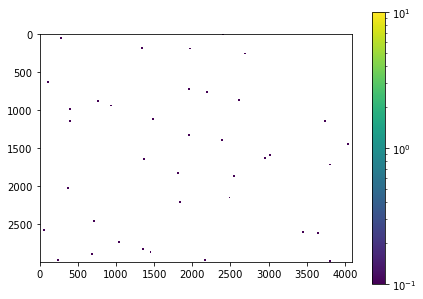

In [6]:
img_np = np.array(img.Array)
print(img_np.shape)
print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np, norm=LogNorm(vmin=1e-1, vmax=1e1))
plt.colorbar()
plt.show()

### Motor control


In [7]:
# Test linear motor control

str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 10.0 mm


In [8]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, 10)  # Move to an absolute position 

str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 10.0 mm


In [9]:
# Test rotary motor control

str_pos_rot_rev = bcs.GetMotorPos(bcs_id_rotary)
pos_rot_rev= float(str_pos_rot_rev.rstrip())

print('rotary stage position is %1.1f rev (1/360deg)' %pos_rot_rev)
print('rotary stage position is %1.1f deg ' %(pos_rot_rev*360))

rotary stage position is 0.0 rev (1/360deg)
rotary stage position is 0.0 deg 


In [10]:
# Move rotary stage
bcs.MoveMotor(bcs_id_rotary, 0.1)  # Move to an RELATIVE position

'Move Started\r\n'

Currently the rotary motor has NO reading, so one has to manually keep track on how/whether it's moved. 

Unlike for linear motor, the MoveMotor for rotary motor is __RELATIVE, i.e., if `bcs.MoveMotor(bcs_id_rotary, 0)`, nothing will be moved__.  


# ALIGNMENT 1125


In [16]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, 0)  # Move to an absolute position 

'Move Started\r\n'

In [17]:
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is 0.0 mm


## Direct Beam on YAG

727305


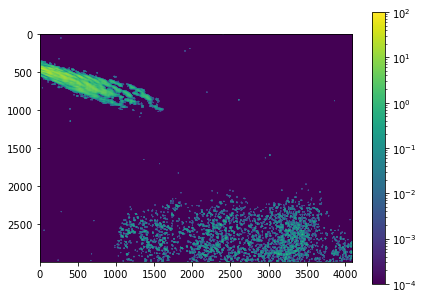

In [19]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

## Move Beam Away

83


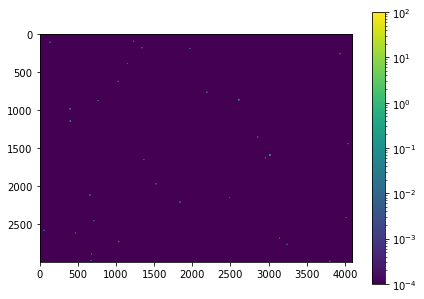

In [20]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

plt.figure(figsize=(7,5))
plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

In [21]:
is_open = True

def toggle():
    global is_open
    is_open = not is_open  # Toggle the state
    return 'open' if is_open else 'close'

# Call this function to toggle the state and display the result
print(toggle())  # Outputs: 'close' (if was 'open' initially)
print(toggle())  # Outputs: 'open' (if was 'close' in previous call)

close
open


In [22]:
bcs.MoveMotor(bcs_id_rotary, 0.5)
print(toggle())

close


In [23]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

# plt.figure(figsize=(7,5))
# plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
# plt.colorbar()
# plt.show()

78


In [67]:
bcs.MoveMotor(bcs_id_rotary, -0.05)

timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

90


In [76]:
bcs.MoveMotor(bcs_id_rotary, 0.5)
print(toggle())

open


In [75]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np_1 = np.array(img.Array)

print(np.sum(img_np_1))

# plt.figure(figsize=(7,5))
# plt.imshow(img_np_1+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
# plt.colorbar()
# plt.show()

77


The current beam that can hit the mirror level cannot go to the YAG, as the mirror is too high. 

In [143]:
# Move linear stage 
bcs.MoveMotor(bcs_id_linear, -8)  # Move to an absolute position 

time.sleep(5)  # Wait for the motor to reach the position
str_pos_lin_mm = bcs.GetMotorPos(bcs_id_linear)
pos_lin_mm = float(str_pos_lin_mm.rstrip())
print('linear stage position is %1.1f mm' %pos_lin_mm)

linear stage position is -8.0 mm


## Alignments

Using the custom defined function. 


In [ ]:
# 20 points with a step of 0.05

sum_intensities = []

for i in range(50):
    value = 0.02  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(0.5)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

Current state: 0.02
Sum intensity: 92
Current state: 0.04
Sum intensity: 84
Current state: 0.06
Sum intensity: 86
Current state: 0.08
Sum intensity: 83
Current state: 0.10
Sum intensity: 85
Current state: 0.12
Sum intensity: 87
Current state: 0.14
Sum intensity: 90
Current state: 0.16
Sum intensity: 91
Current state: 0.18
Sum intensity: 84
Current state: 0.20
Sum intensity: 89
Current state: 0.22
Sum intensity: 88
Current state: 0.24
Sum intensity: 84
Current state: 0.26
Sum intensity: 91
Current state: 0.28
Sum intensity: 85
Current state: 0.30
Sum intensity: 90
Current state: 0.32
Sum intensity: 89
Current state: 0.34
Sum intensity: 85
Current state: 0.36
Sum intensity: 91
Current state: 0.38
Sum intensity: 78
Current state: 0.40
Sum intensity: 74
Current state: 0.42
Sum intensity: 78
Current state: 0.44
Sum intensity: 79
Current state: 0.46
Sum intensity: 7009
Current state: 0.48
Sum intensity: 71
Current state: 0.50
Sum intensity: 78
Current state: 0.52
Sum intensity: 80
Current st

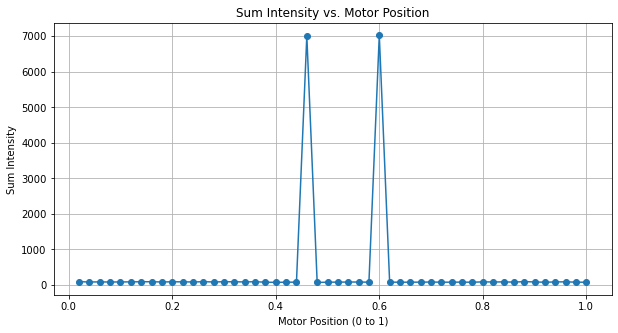

In [ ]:
# Define the x-axis values (0 to 1 with 50 points)
x_values = [(i+1) * 0.02 for i in range(50)]  # Each step of 0.02

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [ ]:
print(x_values[22], sum_intensities[22])
print(x_values[29], sum_intensities[29])

0.46 7009
0.6 7026


CLEAR PEAK AT 0.46 adn 0.6!

Meaning that the beam direction is not optimized. 

In [ ]:
print(move_rotary_motor(.48))

Current state: 0.48
close


Current state: 0.40
None
5271


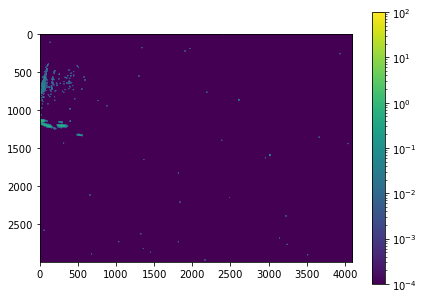

In [ ]:
print(move_rotary_motor(.2))
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Current state: 0.00
open
89


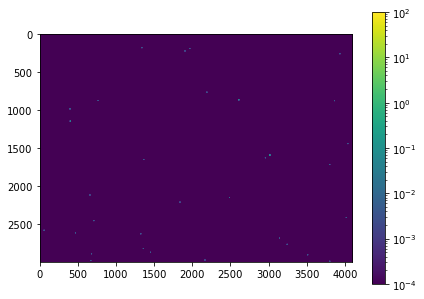

In [ ]:
print(move_rotary_motor(.36))
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Current state: 0.01
Sum intensity: 79
Current state: 0.02
Sum intensity: 78
Current state: 0.03
Sum intensity: 84
Current state: 0.04
Sum intensity: 84
Current state: 0.05
Sum intensity: 81
Current state: 0.06
Sum intensity: 89
Current state: 0.07
Sum intensity: 87
Current state: 0.08
Sum intensity: 86
Current state: 0.09
Sum intensity: 88
Current state: 0.10
Sum intensity: 85
Current state: 0.11
Sum intensity: 89
Current state: 0.12
Sum intensity: 88
Current state: 0.13
Sum intensity: 87
Current state: 0.14
Sum intensity: 86
Current state: 0.15
Sum intensity: 90
Current state: 0.16
Sum intensity: 86
Current state: 0.17
Sum intensity: 84
Current state: 0.18
Sum intensity: 90
Current state: 0.19
Sum intensity: 89
Current state: 0.20
Sum intensity: 87
Current state: 0.21
Sum intensity: 87
Current state: 0.22
Sum intensity: 85
Current state: 0.23
Sum intensity: 79
Current state: 0.24
Sum intensity: 83
Current state: 0.25
Sum intensity: 84
Current state: 0.26
Sum intensity: 74
Current stat

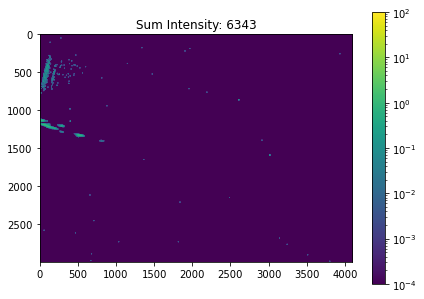

Current state: 0.47
Sum intensity: 75
Current state: 0.48
Sum intensity: 77
Current state: 0.49
Sum intensity: 77
Current state: 0.50
Sum intensity: 74
Current state: 0.51
Sum intensity: 85
Current state: 0.52
Sum intensity: 75
Current state: 0.53
Sum intensity: 84
Current state: 0.54
Sum intensity: 77
Current state: 0.55
Sum intensity: 86
Current state: 0.56
Sum intensity: 95
Current state: 0.57
Sum intensity: 81
Current state: 0.58
Sum intensity: 90
Current state: 0.59
Sum intensity: 76
Current state: 0.60
Sum intensity: 6156


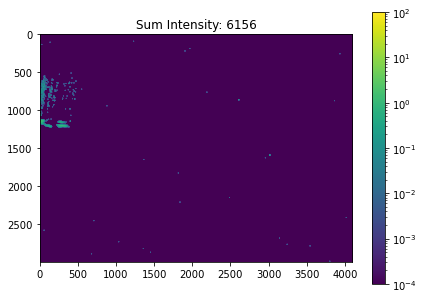

Current state: 0.61
Sum intensity: 131
Current state: 0.62
Sum intensity: 92
Current state: 0.63
Sum intensity: 86
Current state: 0.64
Sum intensity: 95
Current state: 0.65
Sum intensity: 94
Current state: 0.66
Sum intensity: 94
Current state: 0.67
Sum intensity: 84
Current state: 0.68
Sum intensity: 87
Current state: 0.69
Sum intensity: 88
Current state: 0.70
Sum intensity: 81
Current state: 0.71
Sum intensity: 90
Current state: 0.72
Sum intensity: 79
Current state: 0.73
Sum intensity: 91
Current state: 0.74
Sum intensity: 88
Current state: 0.75
Sum intensity: 83
Current state: 0.76
Sum intensity: 90
Current state: 0.77
Sum intensity: 83
Current state: 0.78
Sum intensity: 94
Current state: 0.79
Sum intensity: 92
Current state: 0.80
Sum intensity: 92
Current state: 0.81
Sum intensity: 91
Current state: 0.82
Sum intensity: 84
Current state: 0.83
Sum intensity: 94
Current state: 0.84
Sum intensity: 83
Current state: 0.85
Sum intensity: 83
Current state: 0.86
Sum intensity: 87
Current sta

In [ ]:
# 100 points with a step of 0.01
sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

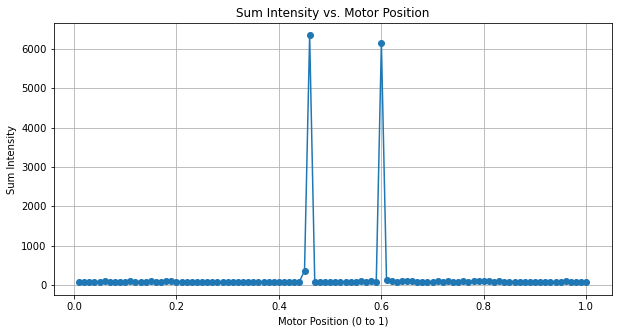

In [ ]:
# Define the x-axis values (0 to 1 with 100 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.grid(True)
plt.show()

In [ ]:
move_rotary_motor(0.46)

Current state: 0.46


'close'

8196


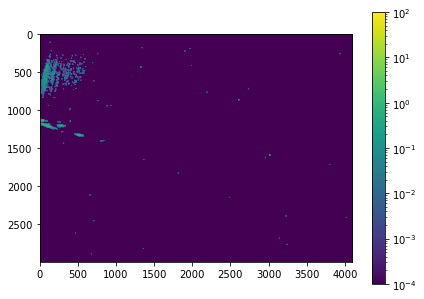

In [ ]:
# Grab an image
timeoutMs = 1000    
img = camera.GrabOne(timeoutMs) # grabbing an image from the camera
camera.Close()                  # releasing the camera
img_np = np.array(img.Array)

print(np.sum(img_np))

plt.figure(figsize=(7,5))
plt.imshow(img_np+1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
plt.colorbar()
plt.show()

Slightly rotate left and right of the laser. 

Current state: 0.01
Sum intensity: 67
Current state: 0.02
Sum intensity: 78
Current state: 0.03
Sum intensity: 69
Current state: 0.04
Sum intensity: 79
Current state: 0.05
Sum intensity: 74
Current state: 0.06
Sum intensity: 79
Current state: 0.07
Sum intensity: 77
Current state: 0.08
Sum intensity: 82
Current state: 0.09
Sum intensity: 73
Current state: 0.10
Sum intensity: 80
Current state: 0.11
Sum intensity: 74
Current state: 0.12
Sum intensity: 79
Current state: 0.13
Sum intensity: 77
Current state: 0.14
Sum intensity: 72
Current state: 0.15
Sum intensity: 68
Current state: 0.16
Sum intensity: 83
Current state: 0.17
Sum intensity: 67
Current state: 0.18
Sum intensity: 78
Current state: 0.19
Sum intensity: 78
Current state: 0.20
Sum intensity: 82
Current state: 0.21
Sum intensity: 78
Current state: 0.22
Sum intensity: 83
Current state: 0.23
Sum intensity: 72
Current state: 0.24
Sum intensity: 80
Current state: 0.25
Sum intensity: 79
Current state: 0.26
Sum intensity: 79
Current stat

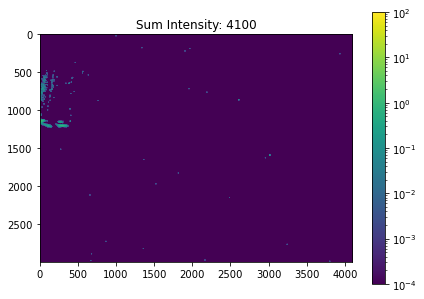

Current state: 0.47
Sum intensity: 85
Current state: 0.48
Sum intensity: 90
Current state: 0.49
Sum intensity: 80
Current state: 0.50
Sum intensity: 76
Current state: 0.51
Sum intensity: 83
Current state: 0.52
Sum intensity: 86
Current state: 0.53
Sum intensity: 80
Current state: 0.54
Sum intensity: 84
Current state: 0.55
Sum intensity: 75
Current state: 0.56
Sum intensity: 84
Current state: 0.57
Sum intensity: 81
Current state: 0.58
Sum intensity: 84
Current state: 0.59
Sum intensity: 680


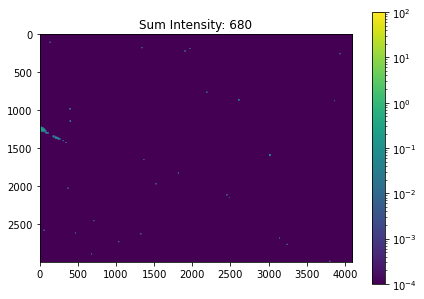

Current state: 0.60
Sum intensity: 6909


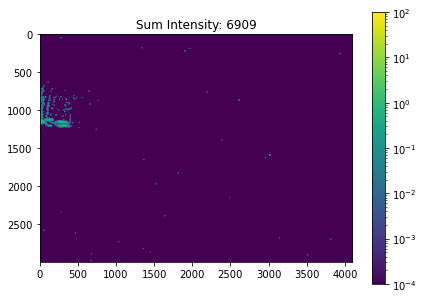

Current state: 0.61
Sum intensity: 78
Current state: 0.62
Sum intensity: 78
Current state: 0.63
Sum intensity: 68
Current state: 0.64
Sum intensity: 77
Current state: 0.65
Sum intensity: 79
Current state: 0.66
Sum intensity: 75
Current state: 0.67
Sum intensity: 76
Current state: 0.68
Sum intensity: 78
Current state: 0.69
Sum intensity: 76
Current state: 0.70
Sum intensity: 77
Current state: 0.71
Sum intensity: 80
Current state: 0.72
Sum intensity: 75
Current state: 0.73
Sum intensity: 80
Current state: 0.74
Sum intensity: 76
Current state: 0.75
Sum intensity: 75
Current state: 0.76
Sum intensity: 77
Current state: 0.77
Sum intensity: 73
Current state: 0.78
Sum intensity: 79
Current state: 0.79
Sum intensity: 79
Current state: 0.80
Sum intensity: 73
Current state: 0.81
Sum intensity: 78
Current state: 0.82
Sum intensity: 74
Current state: 0.83
Sum intensity: 71
Current state: 0.84
Sum intensity: 76
Current state: 0.85
Sum intensity: 79
Current state: 0.86
Sum intensity: 83
Current stat

In [ ]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

In [ ]:
print(move_rotary_motor(0.1))

Current state: 0.35
None


Current state: 0.01
Sum intensity: 73
Current state: 0.02
Sum intensity: 79
Current state: 0.03
Sum intensity: 70
Current state: 0.04
Sum intensity: 73
Current state: 0.05
Sum intensity: 76
Current state: 0.06
Sum intensity: 77
Current state: 0.07
Sum intensity: 81
Current state: 0.08
Sum intensity: 69
Current state: 0.09
Sum intensity: 80
Current state: 0.10
Sum intensity: 72
Current state: 0.11
Sum intensity: 78
Current state: 0.12
Sum intensity: 67
Current state: 0.13
Sum intensity: 66
Current state: 0.14
Sum intensity: 62
Current state: 0.15
Sum intensity: 65
Current state: 0.16
Sum intensity: 72
Current state: 0.17
Sum intensity: 68
Current state: 0.18
Sum intensity: 69
Current state: 0.19
Sum intensity: 65
Current state: 0.20
Sum intensity: 74
Current state: 0.21
Sum intensity: 76
Current state: 0.22
Sum intensity: 66
Current state: 0.23
Sum intensity: 66
Current state: 0.24
Sum intensity: 70
Current state: 0.25
Sum intensity: 73
Current state: 0.26
Sum intensity: 72
Current stat

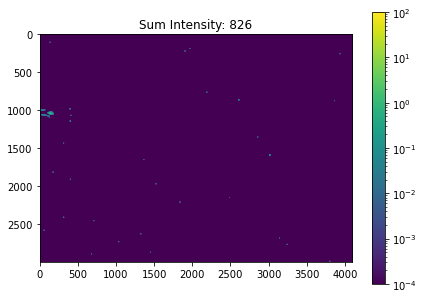

Current state: 0.47
Sum intensity: 3271


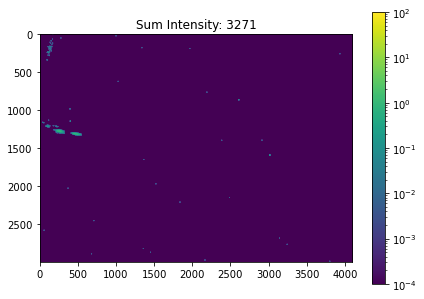

Current state: 0.48
Sum intensity: 78
Current state: 0.49
Sum intensity: 74
Current state: 0.50
Sum intensity: 76
Current state: 0.51
Sum intensity: 76
Current state: 0.52
Sum intensity: 75
Current state: 0.53
Sum intensity: 76
Current state: 0.54
Sum intensity: 75
Current state: 0.55
Sum intensity: 77
Current state: 0.56
Sum intensity: 75
Current state: 0.57
Sum intensity: 84
Current state: 0.58
Sum intensity: 76
Current state: 0.59
Sum intensity: 2399


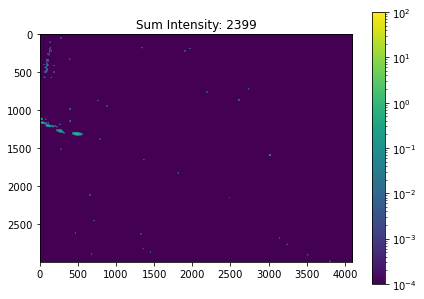

Current state: 0.60
Sum intensity: 651


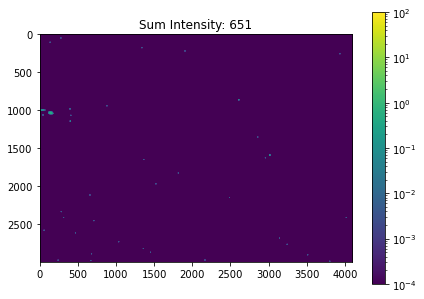

Current state: 0.61
Sum intensity: 76
Current state: 0.62
Sum intensity: 77
Current state: 0.63
Sum intensity: 74
Current state: 0.64
Sum intensity: 80
Current state: 0.65
Sum intensity: 80
Current state: 0.66
Sum intensity: 72
Current state: 0.67
Sum intensity: 76
Current state: 0.68
Sum intensity: 75
Current state: 0.69
Sum intensity: 72
Current state: 0.70
Sum intensity: 77
Current state: 0.71
Sum intensity: 80
Current state: 0.72
Sum intensity: 77
Current state: 0.73
Sum intensity: 80
Current state: 0.74
Sum intensity: 75
Current state: 0.75
Sum intensity: 72
Current state: 0.76
Sum intensity: 76
Current state: 0.77
Sum intensity: 70
Current state: 0.78
Sum intensity: 78
Current state: 0.79
Sum intensity: 74
Current state: 0.80
Sum intensity: 77
Current state: 0.81
Sum intensity: 73
Current state: 0.82
Sum intensity: 73
Current state: 0.83
Sum intensity: 77
Current state: 0.84
Sum intensity: 77
Current state: 0.85
Sum intensity: 79
Current state: 0.86
Sum intensity: 80
Current stat

In [ ]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

In [ ]:
print(move_rotary_motor(0.5))

Current state: 0.00
open


In [ ]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

Current state: 0.01
Sum intensity: 89
Current state: 0.02
Sum intensity: 85
Current state: 0.03
Sum intensity: 83
Current state: 0.04
Sum intensity: 85
Current state: 0.05
Sum intensity: 87
Current state: 0.06
Sum intensity: 85
Current state: 0.07
Sum intensity: 87
Current state: 0.08
Sum intensity: 87
Current state: 0.09
Sum intensity: 82
Current state: 0.10
Sum intensity: 87
Current state: 0.11
Sum intensity: 85
Current state: 0.12
Sum intensity: 85
Current state: 0.13
Sum intensity: 84
Current state: 0.14
Sum intensity: 82
Current state: 0.15
Sum intensity: 85
Current state: 0.16
Sum intensity: 88
Current state: 0.17
Sum intensity: 89
Current state: 0.18
Sum intensity: 83
Current state: 0.19
Sum intensity: 95
Current state: 0.20
Sum intensity: 96
Current state: 0.21
Sum intensity: 87
Current state: 0.22
Sum intensity: 89
Current state: 0.23
Sum intensity: 79
Current state: 0.24
Sum intensity: 94
Current state: 0.25
Sum intensity: 96
Current state: 0.26
Sum intensity: 78
Current stat

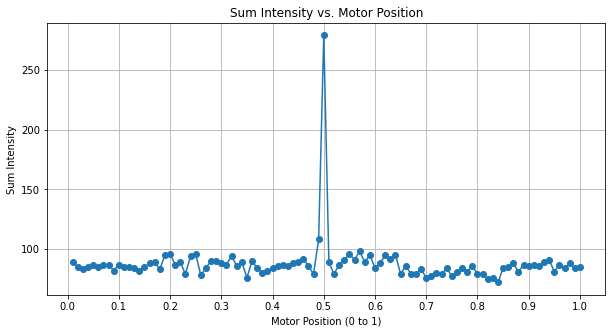

In [ ]:
# Define the x-axis values (0 to 1 with 100 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.xticks(np.arange(0, 1.1, 0.1))  # Set x ticks for clarity
plt.grid(True)
plt.show()

In [ ]:
print(move_rotary_motor(0.5))

Current state: 0.00
open


Current state: 0.01
Sum intensity: 86
Current state: 0.02
Sum intensity: 84
Current state: 0.03
Sum intensity: 84
Current state: 0.04
Sum intensity: 84
Current state: 0.05
Sum intensity: 88
Current state: 0.06
Sum intensity: 86
Current state: 0.07
Sum intensity: 82
Current state: 0.08
Sum intensity: 92
Current state: 0.09
Sum intensity: 89
Current state: 0.10
Sum intensity: 91
Current state: 0.11
Sum intensity: 85
Current state: 0.12
Sum intensity: 92
Current state: 0.13
Sum intensity: 85
Current state: 0.14
Sum intensity: 87
Current state: 0.15
Sum intensity: 85
Current state: 0.16
Sum intensity: 82
Current state: 0.17
Sum intensity: 90
Current state: 0.18
Sum intensity: 85
Current state: 0.19
Sum intensity: 85
Current state: 0.20
Sum intensity: 84
Current state: 0.21
Sum intensity: 96
Current state: 0.22
Sum intensity: 85
Current state: 0.23
Sum intensity: 86
Current state: 0.24
Sum intensity: 94
Current state: 0.25
Sum intensity: 85
Current state: 0.26
Sum intensity: 85
Current stat

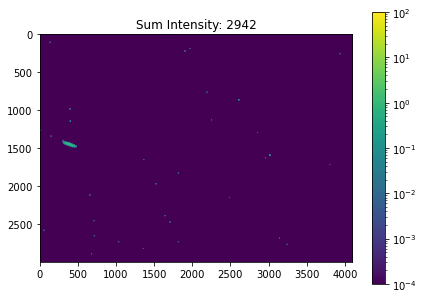

Current state: 0.50
Sum intensity: 521


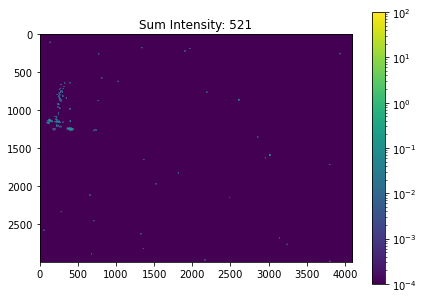

Current state: 0.51
Sum intensity: 87
Current state: 0.52
Sum intensity: 94
Current state: 0.53
Sum intensity: 80
Current state: 0.54
Sum intensity: 83
Current state: 0.55
Sum intensity: 81
Current state: 0.56
Sum intensity: 83
Current state: 0.57
Sum intensity: 83
Current state: 0.58
Sum intensity: 93
Current state: 0.59
Sum intensity: 94
Current state: 0.60
Sum intensity: 88
Current state: 0.61
Sum intensity: 77
Current state: 0.62
Sum intensity: 77
Current state: 0.63
Sum intensity: 92
Current state: 0.64
Sum intensity: 77
Current state: 0.65
Sum intensity: 78
Current state: 0.66
Sum intensity: 76
Current state: 0.67
Sum intensity: 87
Current state: 0.68
Sum intensity: 77
Current state: 0.69
Sum intensity: 87
Current state: 0.70
Sum intensity: 80
Current state: 0.71
Sum intensity: 86
Current state: 0.72
Sum intensity: 76
Current state: 0.73
Sum intensity: 72
Current state: 0.74
Sum intensity: 79
Current state: 0.75
Sum intensity: 82
Current state: 0.76
Sum intensity: 79
Current stat

In [ ]:
# 100 points with a step of 0.01

sum_intensities = []
images_to_plot = []  # List to store images for later plotting

for i in range(100):
    value = 0.01  # Fixed step size
    move_rotary_motor(value)  # Move the motor
    time.sleep(1)           # Wait for 0.5 seconds

    # Grab an image and sum intensity
    timeoutMs = 1000    
    img = camera.GrabOne(timeoutMs)  # Grabbing an image from the camera
    camera.Close()                   # Releasing the camera
    img_np = np.array(img.Array)
    
    intensity_sum = np.sum(img_np)  # Calculate the sum of intensity
    sum_intensities.append(intensity_sum)  # Store the result in the list
    print(f"Sum intensity: {intensity_sum}")  # Print the sum intensity

    # Check the intensity sum and plot the image if it exceeds 500
    if intensity_sum > 500:
        images_to_plot.append(img_np)  # Store the image for later if needed

        # Plot the image
        plt.figure(figsize=(7, 5))
        plt.imshow(img_np + 1e-4, norm=LogNorm(vmin=1e-4, vmax=1e2))
        plt.colorbar()
        plt.title(f'Sum Intensity: {intensity_sum}')
        plt.show()

print(np.array(sum_intensities).shape)
print(np.array(images_to_plot).shape)

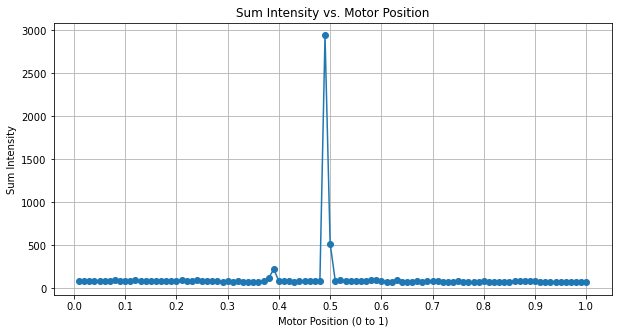

In [ ]:
# Define the x-axis values (0 to 1 with 100 points)
x_values = [(i+1) * 0.01 for i in range(100)]  # Each step of 0.01

# Create the plot
plt.figure(figsize=(10, 5))
plt.plot(x_values, sum_intensities, marker='o')
plt.title('Sum Intensity vs. Motor Position')
plt.xlabel('Motor Position (0 to 1)')
plt.ylabel('Sum Intensity')
plt.xticks(np.arange(0, 1.1, 0.1))  # Set x ticks for clarity
plt.grid(True)
plt.show()

Peak at 0.50!